In [1]:
from azureml.core import Workspace, Dataset
import pandas as pd

# Connect to Azure ML Workspace
ws = Workspace.from_config()

# Load dataset
dataset = Dataset.get_by_name(ws, name="IndianAirlinesCustomerReviewsdataset")

# Convert to Pandas DataFrame
df = dataset.to_pandas_dataframe()

# Display first few rows
df.head()


{'infer_column_types': 'False', 'activity': 'to_pandas_dataframe'}
{'infer_column_types': 'False', 'activity': 'to_pandas_dataframe', 'activityApp': 'TabularDataset'}


,AirLine_Name,Rating - 10,Title,Name,Date,Review,Recommond
0,AirAsia India,6.0,"""crew were welcoming""",V Bakshi,14th October 2023,✅ Trip Verified | I had booked this fare at a ...,yes
1,AirAsia India,1.0,"""furious and disappointed""",G Oscar,14th October 2023,✅ Trip Verified | I travel at least four times...,no
2,AirAsia India,10.0,"""amazing service and support""",Rahul Verma,14th October 2023,✅ Trip Verified | Taking this opportunity to a...,yes
3,AirAsia India,1.0,"""Waste of time and money""",G Akron,14th October 2023,✅ Trip Verified | The worst airlines in the hi...,no
4,AirAsia India,8.0,"""thumbs up to boarding crew""",Sirajudeen Jawahar ali,14th October 2023,✅ Trip Verified | Would like to give big thum...,yes


In [3]:
# Check column names in the dataset
df.columns


Index(['AirLine_Name', 'Rating - 10', 'Title', 'Name', 'Date', 'Review',
       'Recommond'],
      dtype='object')

In [5]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')  # Standardize column names
print(df.columns)  # Check again


Index(['airline_name', 'rating_-_10', 'title', 'name', 'date', 'review',
       'recommond'],
      dtype='object')


In [6]:
for col in df.columns:
    print(col)


airline_name
rating_-_10
title
name
date
review
recommond


In [7]:
import re
import string

# Function to clean text
def clean_text(text):
    if isinstance(text, str):
        text = text.lower()  # Convert to lowercase
        text = re.sub(r'\d+', '', text)  # Remove numbers
        text = text.translate(str.maketrans('', '', string.punctuation))  # Remove punctuation
        text = ' '.join(word for word in text.split() if len(word) > 2)  # Remove short words
        return text.strip()
    return ""

# Apply text cleaning using the correct column name
df['cleaned_review'] = df['review'].apply(clean_text)

# Display cleaned data
df[['review', 'cleaned_review']].head()


,review,cleaned_review
0,✅ Trip Verified | I had booked this fare at a ...,trip verified had booked this fare very discou...
1,✅ Trip Verified | I travel at least four times...,trip verified travel least four times month an...
2,✅ Trip Verified | Taking this opportunity to a...,trip verified taking this opportunity apprecia...
3,✅ Trip Verified | The worst airlines in the hi...,trip verified the worst airlines the history m...
4,✅ Trip Verified | Would like to give big thum...,trip verified would like give big thumbs board...


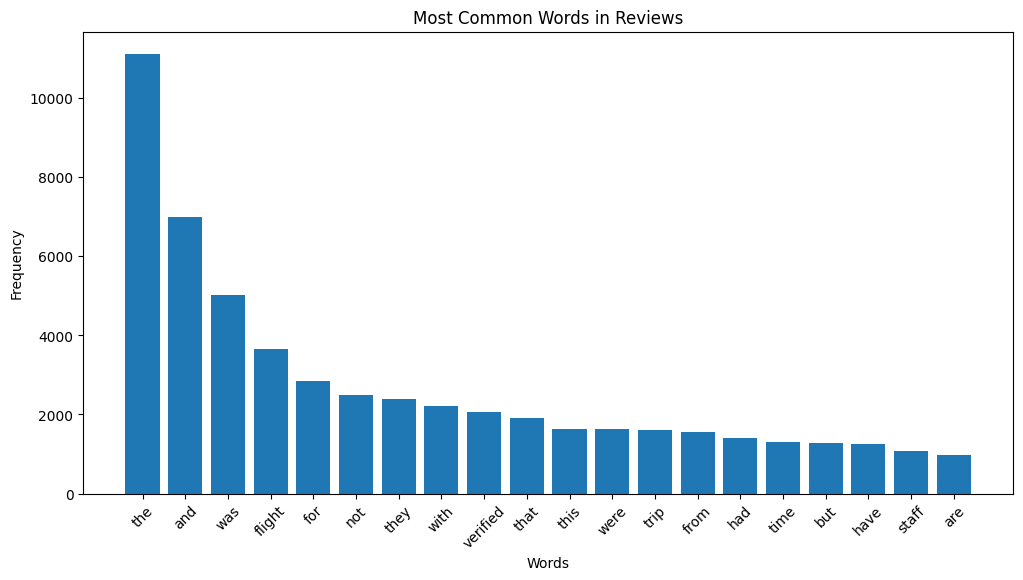

In [9]:
from collections import Counter
import matplotlib.pyplot as plt

# Split words and count occurrences
words = ' '.join(df['cleaned_review'].dropna()).split()
word_counts = Counter(words)

# Get the top 20 most common words
top_words = word_counts.most_common(20)

# Separate words and counts for visualization
words, counts = zip(*top_words)

# Plot word frequency bar chart
plt.figure(figsize=(12, 6))
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.title("Most Common Words in Reviews")
plt.show()


In [11]:
from collections import Counter

# Function to extract bigrams
def get_ngrams(text, n=2):
    words = text.split()
    return list(zip(*[words[i:] for i in range(n)]))

# Extract bigrams from all reviews
bigrams = []
df['cleaned_review'].dropna().apply(lambda x: bigrams.extend(get_ngrams(x, 2)))

# Count bigrams
bigram_counts = Counter(bigrams)

# Display top 10 bigrams
top_bigrams = bigram_counts.most_common(10)
print("Top 10 Bigrams in Reviews:")
for bigram, count in top_bigrams:
    print(f"{bigram}: {count}")


Top 10 Bigrams in Reviews:
('trip', 'verified'): 1480
('the', 'flight'): 1091
('air', 'india'): 691
('not', 'verified'): 500
('flight', 'was'): 490
('and', 'the'): 485
('for', 'the'): 471
('was', 'not'): 293
('cabin', 'crew'): 272
('the', 'airport'): 265


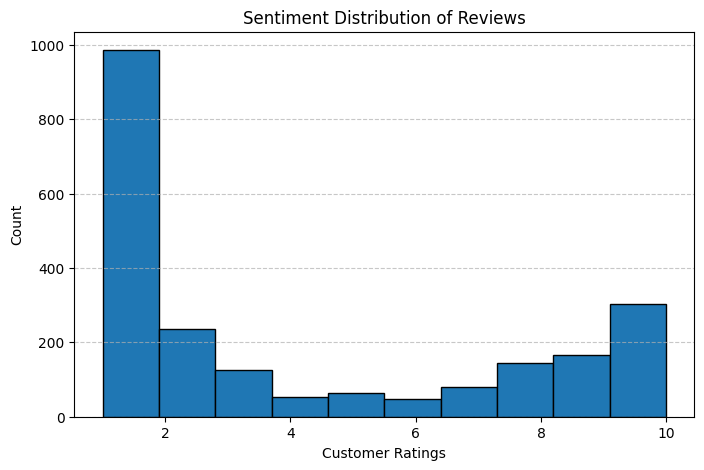

In [13]:
import matplotlib.pyplot as plt

# Check if "rating_-_10" column exists
if 'rating_-_10' in df.columns:
    plt.figure(figsize=(8, 5))
    plt.hist(df['rating_-_10'].dropna(), bins=10, edgecolor='black')  # Use Matplotlib's histogram
    plt.xlabel("Customer Ratings")
    plt.ylabel("Count")
    plt.title("Sentiment Distribution of Reviews")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
else:
    print("Column 'rating_-_10' not found in dataset.")


Bag of Words Representation (First 5 Rows):


,able,about,above,absolutely,accept,actual,actually,add,added,additional,...,would,wouldnt,writing,wrong,year,years,yet,you,your,zero
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,2,0,0
3,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0


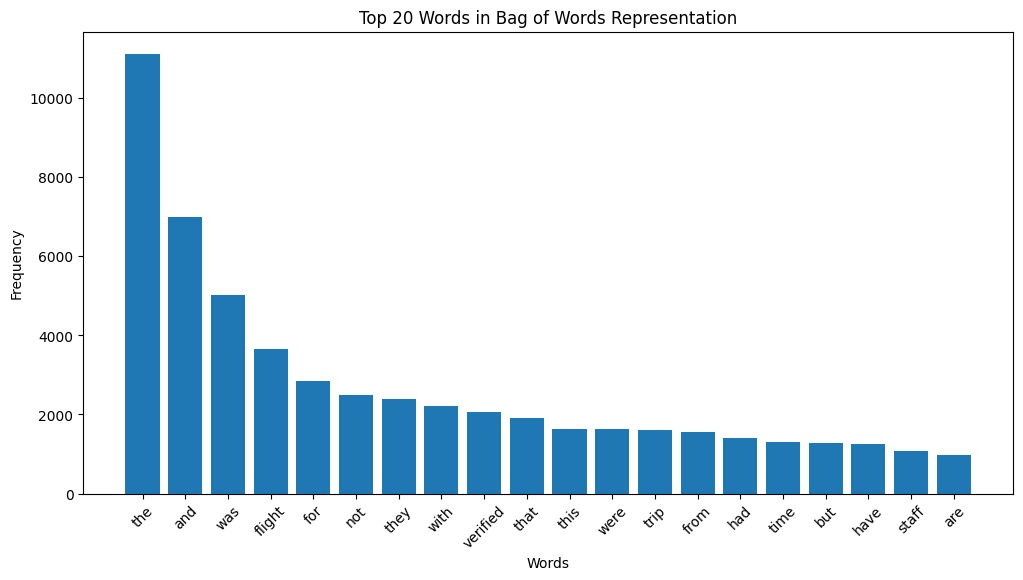

In [14]:
from sklearn.feature_extraction.text import CountVectorizer

# Convert text into BoW features
vectorizer = CountVectorizer(max_features=1000)  # Keep only the top 1000 words
X_bow = vectorizer.fit_transform(df['cleaned_review'].dropna())

# Convert to DataFrame
bow_df = pd.DataFrame(X_bow.toarray(), columns=vectorizer.get_feature_names_out())

# Display first few features
import matplotlib.pyplot as plt

print("Bag of Words Representation (First 5 Rows):")
display(bow_df.head())

# Plot the top words
word_counts = X_bow.toarray().sum(axis=0)
top_words = sorted(zip(vectorizer.get_feature_names_out(), word_counts), key=lambda x: x[1], reverse=True)[:20]

# Plot the top 20 words
words, counts = zip(*top_words)
plt.figure(figsize=(12, 6))
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.title("Top 20 Words in Bag of Words Representation")
plt.show()


TF-IDF Representation (First 5 Rows):


,able,about,above,absolutely,accept,actual,actually,add,added,additional,...,would,wouldnt,writing,wrong,year,years,yet,you,your,zero
0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
1,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
2,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.061403,0.0,0.0,0.0,0.0,0.0,0.0,0.115088,0.0,0.0
3,0.0,0.0,0.0,0.347076,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
4,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.101165,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0


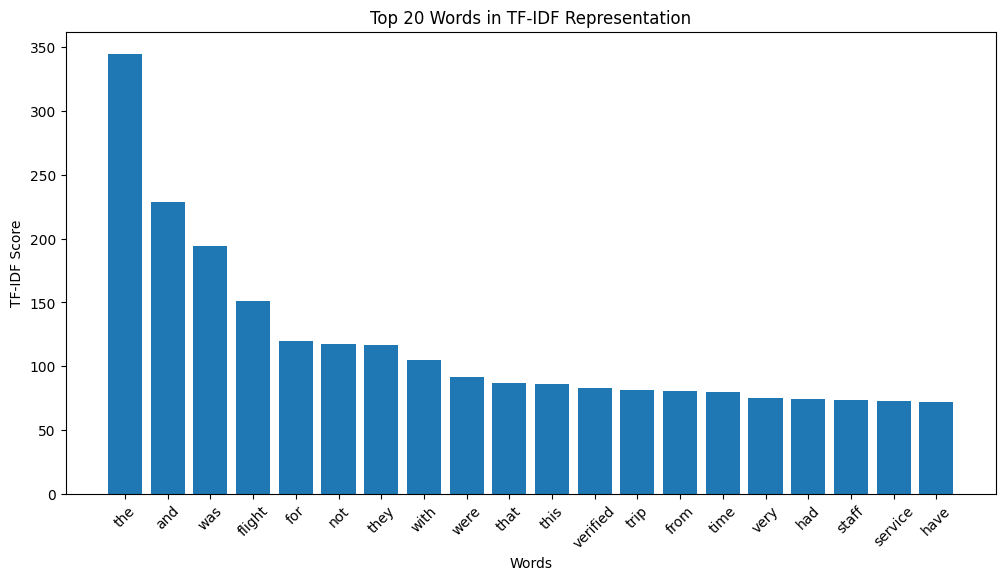

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Convert text into TF-IDF features
tfidf_vectorizer = TfidfVectorizer(max_features=1000)  # Keep only top 1000 words
X_tfidf = tfidf_vectorizer.fit_transform(df['cleaned_review'].dropna())

# Convert to DataFrame
tfidf_df = pd.DataFrame(X_tfidf.toarray(), columns=tfidf_vectorizer.get_feature_names_out())

# Display first few features
print("TF-IDF Representation (First 5 Rows):")
display(tfidf_df.head())

# Plot the top words
word_tfidf = X_tfidf.toarray().sum(axis=0)
top_tfidf_words = sorted(zip(tfidf_vectorizer.get_feature_names_out(), word_tfidf), key=lambda x: x[1], reverse=True)[:20]

# Plot the top 20 words
words, scores = zip(*top_tfidf_words)
plt.figure(figsize=(12, 6))
plt.bar(words, scores)
plt.xticks(rotation=45)
plt.xlabel("Words")
plt.ylabel("TF-IDF Score")
plt.title("Top 20 Words in TF-IDF Representation")
plt.show()


In [16]:
df_processed = pd.concat([df[['cleaned_review', 'rating_-_10']], bow_df, tfidf_df], axis=1)
df_processed.to_csv("Processed_Airlines_Reviews.csv", index=False)
print("Processed dataset saved!")


Processed dataset saved!


In [17]:
# Save the processed dataset to the working directory in Azure
df_processed = pd.concat([df[['cleaned_review', 'rating_-_10']], bow_df, tfidf_df], axis=1)
df_processed.to_csv("Processed_Airlines_Reviews.csv", index=False)

print("Processed dataset saved as 'Processed_Airlines_Reviews.csv'")


Processed dataset saved as 'Processed_Airlines_Reviews.csv'
